In [1]:
import pandas as pd
import numpy as num
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("TN womens crime datasets.txt")

In [4]:
print(df.head())

   Year    District         Area  Crime_Type  Victim_Age     Time Urban_Rural  \
0  2021     Chennai      T Nagar        Rape          23    Night       Urban   
1  2021     Chennai    Velachery     Assault          31  Evening       Urban   
2  2021     Chennai     Tambaram  Kidnapping          17    Night       Urban   
3  2021  Coimbatore  Gandhipuram        Rape          26    Night       Urban   
4  2021  Coimbatore     RS Puram     Assault          35  Morning       Urban   

   Police_Station  Crime_Count  
0      T Nagar PS           18  
1    Velachery PS            9  
2     Tambaram PS           14  
3  Gandhipuram PS           20  
4     RS Puram PS            6  


In [5]:
print(df.isnull().sum())

Year              0
District          0
Area              0
Crime_Type        0
Victim_Age        0
Time              0
Urban_Rural       0
Police_Station    0
Crime_Count       0
dtype: int64


In [6]:
def safety_level(crime_count):

    if crime_count <= 5:
        return "Low"

    elif crime_count <= 15:
        return "Medium"

    else:
        return "High Danger"


In [7]:
df['Safety_Level'] = df['Crime_Count'].apply(safety_level)
print(df[['District',
          'Area',
          'Crime_Count',
          'Safety_Level']].head())


     District         Area  Crime_Count Safety_Level
0     Chennai      T Nagar           18  High Danger
1     Chennai    Velachery            9       Medium
2     Chennai     Tambaram           14       Medium
3  Coimbatore  Gandhipuram           20  High Danger
4  Coimbatore     RS Puram            6       Medium


In [8]:
district_analysis = df.groupby('District')[
    'Crime_Count'
].sum()

print("\nTop Dangerous Districts\n")

print(district_analysis.sort_values(
    ascending=False
).head(10))


Top Dangerous Districts

District
Chennai       298
Coimbatore    155
Madurai       145
Trichy        106
Cuddalore     103
Tiruppur      100
Dindigul       82
Erode          80
Namakkal       80
Nilgiris       70
Name: Crime_Count, dtype: int64


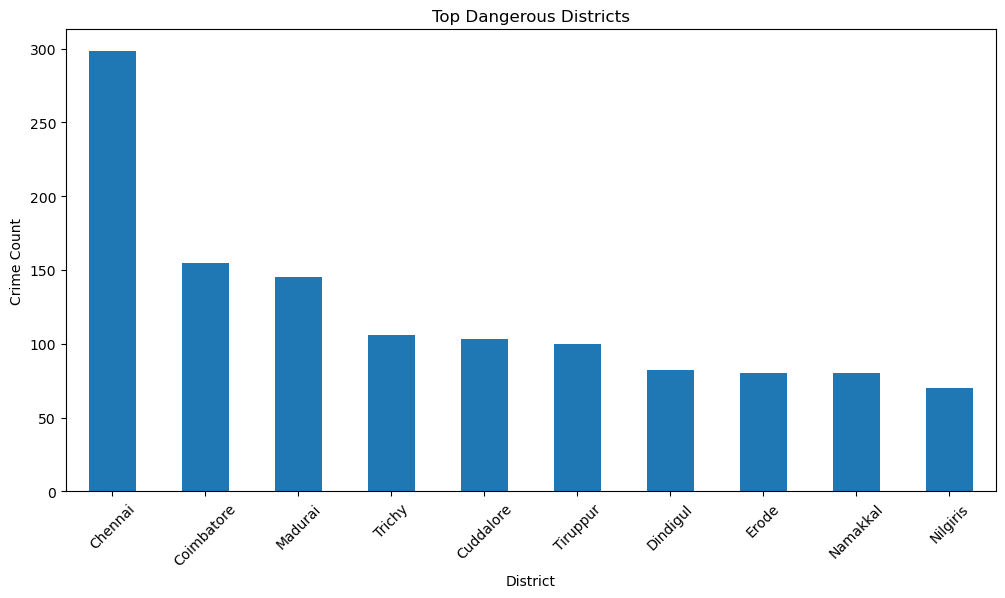

In [9]:
plt.figure(figsize=(12,6))

district_analysis.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top Dangerous Districts")
plt.xlabel("District")
plt.ylabel("Crime Count")

plt.xticks(rotation=45)

plt.show()

In [10]:
rape_data = df[df['Crime_Type'] == 'Rape']

rape_by_district = rape_data.groupby(
    'District'
)['Crime_Count'].sum()

top_rape = rape_by_district.sort_values(
    ascending=False
).head(10)

print(top_rape)

District
Coimbatore    120
Chennai       114
Trichy        106
Cuddalore     103
Tiruppur      100
Madurai        95
Dindigul       82
Erode          80
Nilgiris       70
Name: Crime_Count, dtype: int64


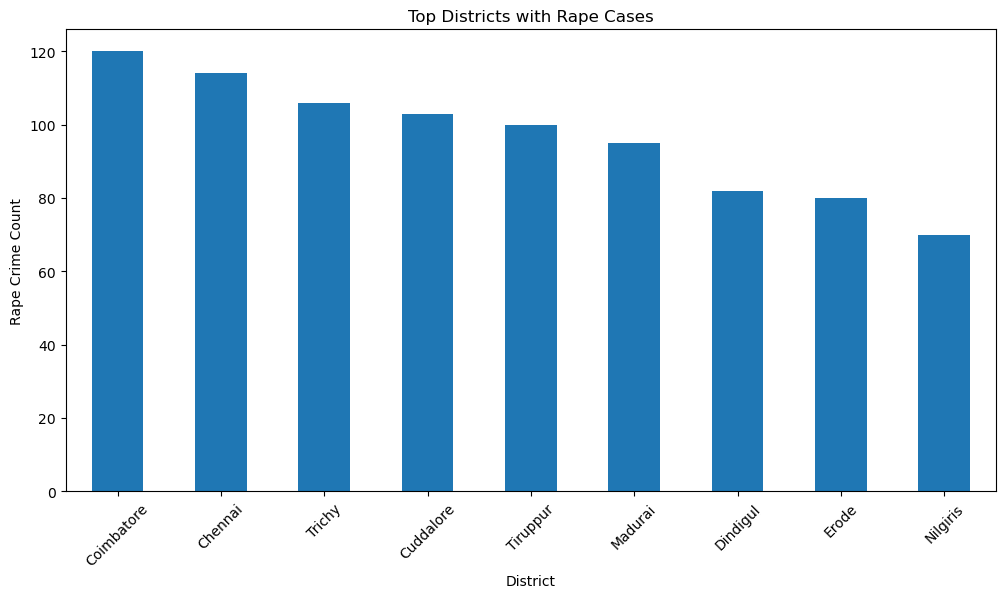

In [11]:
plt.figure(figsize=(12,6))

top_rape.plot(kind='bar')

plt.title("Top Districts with Rape Cases")
plt.xlabel("District")
plt.ylabel("Rape Crime Count")

plt.xticks(rotation=45)

plt.show()

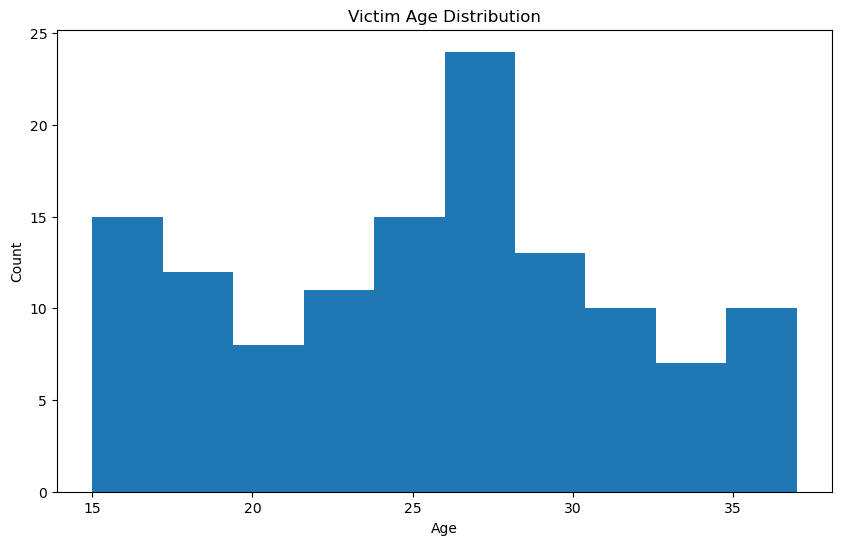

In [12]:
plt.figure(figsize=(10,6))

plt.hist(df['Victim_Age'])

plt.title("Victim Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns = [
    'District',
    'Area',
    'Crime_Type',
    'Time',
    'Urban_Rural',
    'Police_Station'
]

for col in columns:

    df[col] = le.fit_transform(df[col])


In [15]:
X = df[[
    'Year',
    'District',
    'Area',
    'Crime_Type',
    'Victim_Age',
    'Time',
    'Urban_Rural',
    'Police_Station'
]]


y = df['Crime_Count']

In [22]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
predictions = model.predict(X_test)

print("\nPredicted Crime Counts\n")

print(predictions)



Predicted Crime Counts

[14.29  6.72  5.42 10.67 21.41 17.85  9.03  8.56 15.31  6.54 15.17 20.32
 19.5  12.92 18.16 16.08 14.73 10.79  5.02  9.01 12.41 23.54 20.78  8.32
  7.52]


In [28]:
score = model.score(X_test, y_test)

print("\nModel Accuracy Score : ", score)



Model Accuracy Score :  0.9141343615565115


In [31]:
sample_data = pd.DataFrame([[
    2027,
    3,
    12,
    2,
    24,
    2,
    1,
    15
]], columns=[
    'Year',
    'District',
    'Area',
    'Crime_Type',
    'Victim_Age',
    'Time',
    'Urban_Rural',
    'Police_Station'
])

future_prediction = model.predict(sample_data)

predicted_crime = future_prediction[0]

print("\nPredicted Future Crime Count : ",
      predicted_crime)



Predicted Future Crime Count :  18.81


In [30]:
if predicted_crime <= 5:

    safety = "Low"

elif predicted_crime <= 15:

    safety = "Medium"

else:

    safety = "High Danger"

print("Predicted Safety Level : ", safety)

Predicted Safety Level :  High Danger
